# Zero-shot → Few-shot: CheXpert **and** ChestX-ray14

One model, one protocol, two test sets — so any difference between them is the *dataset*,
not the model.

## What we are reproducing

| | CheXzero (Tiu et al. 2022, Table 2) |
|---|---|
| **CheXzero zero-shot, CheXpert test** | **0.889** |
| DAM (supervised SOTA) | 0.931 |
| DenseNet-121 (supervised) | 0.902 |
| MoCo-CXR, 100% labels | 0.884 |
| ConVIRT-ResNet-50, 100% labels | 0.881 |

## Deliverables

1. **Zero-shot on CheXpert test** vs the 0.889 headline.
2. **Zero-shot on ChestX-ray14 test** (14 labels).
3. **Few-shot sweep, K = 1…64, on both.**
4. **Head-to-head on the five pathologies that appear in both datasets.**

## Protocol, matched to the paper

| | |
|---|---|
| Training | MIMIC-CXR, 377,110 pairs, all views, **impression only** (`mimic_impressions.csv`) |
| Recipe | ViT-B/32 from CLIP, batch 64, SGD lr 1e-4, momentum 0.9, 8 epochs |
| Selection | CheXpert **val**, 200 studies, mean AUC over the 5 competition tasks |
| Ensemble | top-10 checkpoints, probabilities averaged after softmax |
| Prompts | `"{}"` / `"no {}"` — the paper's bare-label frame, **no tuning** |

Training runs 8 epochs and selection picks the best checkpoint wherever it lands, so the
4-vs-8 epoch question is settled by the ranking rather than assumed.

## The two evaluations

| | CheXpert | ChestX-ray14 |
|---|---|---|
| Test | 500 studies, `view1` frontal, one per study | 25,596 images, `test_list.txt` |
| Test labels | majority vote of 5 radiologists, clean 0/1 | NIH, from `Data_Entry_2017_v2020.csv` |
| Few-shot support | CheXpert **train**, 10,000 frontal sample | `nih_promptdev.h5`, 20,000 from `train_val_list.txt` |
| Support labels | CheXpert labeler (machine), `-1` dropped | NIH, clean 0/1 |
| Labels scored | 5 competition tasks | 14 pathologies |

Both support pools are disjoint from their test sets — asserted below.

**One NIH label caps out.** Hernia has only **37** positives in the 20,000-image support pool,
so K = 64 is impossible for it; the sampler falls back to `min(K, available)` per label rather
than failing. Every CheXpert label supports the full sweep (the scarcest, Consolidation, has
~700 positives in 10,000).

## Label quality — state this in any write-up

CheXpert **val** and **test** are radiologist-labeled with no uncertainty. CheXpert **train**
is machine-labeled by the rule-based CheXpert labeler and carries `-1` (uncertain); for
Consolidation there are more uncertain than positive. All `-1` rows are dropped from the
support pool. **We adapt on machine labels and test on radiologist labels.**

**Blank labels.** In CheXpert, blank means "the report did not mention it". The official
evaluation and `test_labels.csv` both treat blank as **negative**, so the sampler does too.
Restricting negatives to explicit `0` would draw only from reports that said "no &lt;label&gt;" —
for Atelectasis that is ~1% of the pool.

**Kernel:** the `hj` conda environment (`/home/hj/anaconda3/envs/hj/bin/python`).

In [1]:
import os, sys, hashlib
import numpy as np, pandas as pd, torch, h5py
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

ROOT     = "/mnt/My_Doc/github/xray_clip/"
CHEXZERO = ROOT + "CheXzero/"
sys.path.insert(0, CHEXZERO)
os.chdir(CHEXZERO)

import clip
from zero_shot import load_clip
from select_checkpoints import make_loader, CXR_LABELS_5
from eval_nih import NIH_LABELS, LABEL_PROMPTS, build_groundtruth as nih_groundtruth

EXP = os.environ.get("CX_EXP_DIR", "/mnt/My_Doc/experiments/chexpert_v1/")
OUT = os.path.join(EXP, "results/"); os.makedirs(OUT, exist_ok=True)

TOPK    = int(os.environ.get("CX_TOPK", 10))
SEEDS   = int(os.environ.get("CX_SEEDS", 20))
K_SWEEP = [1, 2, 4, 8, 16, 32, 64]
BATCH, CTX = 256, 77
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

RANKING = os.environ.get("CX_RANKING", os.path.join(EXP, "checkpoint_ranking.csv"))
CKPTS   = pd.read_csv(RANKING)["checkpoint"].tolist()[:TOPK]

CXP_TEST_LABELS  = "/mnt/My_Doc/dataset/CXR_dataset/CheXpert/chexlocalize/chexlocalize/CheXpert/test_labels.csv"
CXP_TRAIN_LABELS = "/mnt/My_Doc/dataset/CXR_dataset/CheXpert/kaggle/train.csv"
NIH_ENTRY        = "/mnt/My_Doc/dataset/CXR_dataset/ChestXray14/cxr8/Data_Entry_2017_v2020.csv"

print(f"device      : {DEVICE}")
print(f"checkpoints : {len(CKPTS)}  (best = {os.path.basename(CKPTS[0])})")
print(f"outputs     : {OUT}")

device      : cuda:0
checkpoints : 10  (best = checkpoint_32200.pt)
outputs     : /mnt/My_Doc/experiments/chexpert_v1/results/


## 1. Ground truth for both datasets

Every label matrix must follow its h5 row order exactly. Misalignment trains and scores on
mismatched pairs while the numbers still look plausible, so each join is asserted.

In [ ]:
study_key = lambda s: s.str.extract(r"(patient\d+/study\d+)")[0]

# ============================ CheXpert ============================================
cxp_test_paths = os.path.join(EXP, "chexpert_test_paths.csv")
cxp_supp_paths = os.path.join(EXP, "chexpert_support_paths.csv")

tp     = pd.read_csv(cxp_test_paths)["Path"]
tl_raw = pd.read_csv(CXP_TEST_LABELS)
# test_labels.csv has one row per IMAGE (668) but the h5 holds one frontal per STUDY (500).
# CheXpert labels are study-level -- verified: no study has differing labels across its views --
# so collapse to one row per study before joining. Without this, .loc on a duplicated index
# silently returns 668 rows and every downstream array is misaligned.
tl_raw["study"] = study_key(tl_raw.Path)
assert (tl_raw.groupby("study")[CXR_LABELS_5].nunique() <= 1).all().all(), \
    "CheXpert test labels differ across views of the same study"
tl = tl_raw.drop_duplicates("study").set_index("study")
order = study_key(tp)
assert not (set(order) - set(tl.index)), "test studies missing from labels"
assert len(order) == len(set(order)) == 500, f"expected 500 unique test studies, got {len(order)}"
y_cxp_test = tl.loc[order, CXR_LABELS_5].to_numpy(dtype=float)

# train.csv carries a release prefix ("CheXpert-v1.0-small/"); h5 paths are absolute.
# Extract the shared train/patient/study/view suffix from both sides so the join cannot slip.
PAT = r"(train/patient\d+/study\d+/view\d+_\w+\.jpg)"
tr = pd.read_csv(CXP_TRAIN_LABELS)
tr["k"] = tr.Path.str.extract(PAT)[0]
tr = tr.dropna(subset=["k"]).drop_duplicates("k").set_index("k")
sp = pd.read_csv(cxp_supp_paths)["Path"]
skey = sp.str.extract(PAT)[0]
assert skey.notna().all(), "support paths do not match the expected CheXpert layout"
assert skey.isin(tr.index).all(), "some support images have no row in train.csv"
y_cxp_supp = tr.loc[skey, CXR_LABELS_5].to_numpy(dtype=float)   # 1 / 0 / -1 / nan

# ============================ ChestX-ray14 ========================================
nih_test_paths = "data/nih_test_paths.csv"
nih_supp_paths = "data/nih_promptdev_paths.csv"
y_nih_test = nih_groundtruth(NIH_ENTRY, nih_test_paths, list(NIH_LABELS))
y_nih_supp = nih_groundtruth(NIH_ENTRY, nih_supp_paths, list(NIH_LABELS))

# ============================ registry ============================================
DATA = {
    "CheXpert": dict(labels=list(CXR_LABELS_5),
                     test_h5=os.path.join(EXP, "chexpert_test.h5"),
                     supp_h5=os.path.join(EXP, "chexpert_support.h5"),
                     y_test=y_cxp_test, y_supp=y_cxp_supp,
                     test_paths=cxp_test_paths, supp_paths=cxp_supp_paths,
                     prompt={l: l for l in CXR_LABELS_5}),
    "NIH": dict(labels=list(NIH_LABELS),
                test_h5="data/nih_test.h5", supp_h5="data/nih_promptdev.h5",
                y_test=y_nih_test, y_supp=y_nih_supp,
                test_paths=nih_test_paths, supp_paths=nih_supp_paths,
                prompt={l: LABEL_PROMPTS.get(l, l) for l in NIH_LABELS}),
}

for name, d in DATA.items():
    for split in ("test", "supp"):
        with h5py.File(d[f"{split}_h5"], "r") as f:
            n = f["cxr"].shape[0]
        assert n == len(d[f"y_{split}"]), f"{name}/{split}: h5 {n} vs labels {len(d[f'y_{split}'])}"
    # Compare full paths, not basenames: every CheXpert file is literally named
    # "view1_frontal.jpg", so a basename comparison reports a collision for any two
    # CheXpert sets and means nothing. Patient id is also checked for CheXpert.
    full = lambda p: set(pd.read_csv(p)["Path"])
    ov = full(d["test_paths"]) & full(d["supp_paths"])
    pid = lambda p: set(pd.read_csv(p)["Path"].str.extract(r"(patient\d+)")[0].dropna())
    ov |= (pid(d["test_paths"]) & pid(d["supp_paths"])) if name == "CheXpert" else set()
    print(f"{name:<9} test {len(d['y_test']):>6,} x {len(d['labels']):>2}   "
          f"support {len(d['y_supp']):>6,}   test/support overlap {len(ov)}  "
          f"{'OK' if not ov else 'LEAKAGE - STOP'}")

CheXpert  test    500 x  5   support 10,000   test/support overlap 0  OK
NIH       test 25,596 x 14   support 20,000   test/support overlap 0  OK


In [3]:
for name, d in DATA.items():
    print(f"\n=== {name} ===")
    print(f"{'label':<20}{'test pos':>10}{'supp pos':>10}{'supp neg':>10}{'dropped -1':>12}")
    for i, l in enumerate(d["labels"]):
        c = d["y_supp"][:, i]
        neg = int(((c == 0) | np.isnan(c)).sum())
        print(f"{l:<20}{int(d['y_test'][:, i].sum()):>10}{int((c == 1).sum()):>10}"
              f"{neg:>10}{int((c == -1).sum()):>12}")


=== CheXpert ===
label                 test pos  supp pos  supp neg  dropped -1
Atelectasis                153      1554      6894        1552
Cardiomegaly               151      1250      8428         322
Consolidation               29       701      8040        1259
Edema                       78      2642      6731         627
Pleural Effusion           104      4145      5376         479

=== NIH ===
label                 test pos  supp pos  supp neg  dropped -1
Atelectasis               3279      1801     18199           0
Cardiomegaly              1069       409     19591           0
Effusion                  4658      1883     18117           0
Infiltration              6112      2770     17230           0
Mass                      1748       817     19183           0
Nodule                    1623      1039     18961           0
Pneumonia                  555       187     19813           0
Pneumothorax              2665       593     19407           0
Consolidation           

## 2. Encode once

Image features depend on neither K, nor the seed, nor the prompt. Encode all four sets once
per checkpoint, cache to disk, and everything afterwards is matrix arithmetic.

In [4]:
def encode(h5_path, ckpts, tag):
    k = hashlib.md5(("|".join(ckpts) + h5_path).encode()).hexdigest()[:10]
    cache = os.path.join(OUT, f"feat_{tag}_{k}.npy")
    if os.path.exists(cache):
        a = np.load(cache); print(f"{tag}: cache hit {a.shape}"); return torch.from_numpy(a)
    loader, out = make_loader(h5_path, BATCH), []
    for i, c in enumerate(ckpts, 1):
        m = load_clip(model_path=c, pretrained=True, context_length=CTX).to(DEVICE).eval()
        ch = []
        with torch.no_grad():
            for b in loader:
                f = m.encode_image(b["img"].to(DEVICE))
                ch.append((f / f.norm(dim=-1, keepdim=True)).float().cpu())
        out.append(torch.cat(ch))
        print(f"  {tag} [{i}/{len(ckpts)}] -> {tuple(out[-1].shape)}", flush=True)
        del m
        if DEVICE.type == "cuda": torch.cuda.empty_cache()
    a = torch.stack(out).numpy(); np.save(cache, a); print(f"{tag}: cached {a.shape}")
    return torch.from_numpy(a)

for name, d in DATA.items():
    d["F_test"] = encode(d["test_h5"], CKPTS, f"{name}_test")
    d["F_supp"] = encode(d["supp_h5"], CKPTS, f"{name}_supp")

CheXpert_test: cache hit (10, 500, 512)
CheXpert_supp: cache hit (10, 10000, 512)
NIH_test: cache hit (10, 25596, 512)
NIH_supp: cache hit (10, 20000, 512)


## 3. Prompts

The paper's frame, unchanged:

> *"We run experiments using the labels present in the test set as the prompts and creating the
> prompts of '&lt;label&gt;' and 'no &lt;label&gt;' as the positive and negative prompts."*

No tuning — the point of this notebook is the faithful comparison against 0.889. Two NIH label
names are not usable verbatim (`Effusion` is ambiguous, `Pleural_Thickening` tokenises badly),
so they carry their radiological phrasing; everything else is the bare label.

In [5]:
def encode_texts(ckpts, strings):
    k = hashlib.md5(("|".join(ckpts) + "|".join(strings)).encode()).hexdigest()[:10]
    cache = os.path.join(OUT, f"text_{k}.npz")
    if os.path.exists(cache):
        z = np.load(cache); return {s: torch.from_numpy(z[str(i)]) for i, s in enumerate(strings)}
    acc = {s: [] for s in strings}
    for c in ckpts:
        m = load_clip(model_path=c, pretrained=True, context_length=CTX).to(DEVICE).eval()
        with torch.no_grad():
            e = m.encode_text(clip.tokenize(strings, context_length=CTX).to(DEVICE))
            e = (e / e.norm(dim=-1, keepdim=True)).float().cpu()
        for s, v in zip(strings, e): acc[s].append(v)
        del m
        if DEVICE.type == "cuda": torch.cuda.empty_cache()
    o = {s: torch.stack(v) for s, v in acc.items()}
    np.savez(cache, **{str(i): o[s].numpy() for i, s in enumerate(strings)})
    return o

for d in DATA.values():
    d["pos_s"] = {l: d["prompt"][l] for l in d["labels"]}
    d["neg_s"] = {l: "no " + d["prompt"][l] for l in d["labels"]}
STRINGS = sorted({s for d in DATA.values() for m in ("pos_s", "neg_s") for s in d[m].values()})
T = encode_texts(CKPTS, STRINGS)
print(f"encoded {len(T)} prompt strings, each {tuple(next(iter(T.values())).shape)}")
for name, d in DATA.items():
    print(f"\n{name}:")
    for l in d["labels"][:3]:
        print(f"  {l:<20} {d['pos_s'][l]!r:<26} vs {d['neg_s'][l]!r}")

encoded 28 prompt strings, each (10, 512)

CheXpert:
  Atelectasis          'Atelectasis'              vs 'no Atelectasis'
  Cardiomegaly         'Cardiomegaly'             vs 'no Cardiomegaly'
  Consolidation        'Consolidation'            vs 'no Consolidation'

NIH:
  Atelectasis          'Atelectasis'              vs 'no Atelectasis'
  Cardiomegaly         'Cardiomegaly'             vs 'no Cardiomegaly'
  Effusion             'Pleural Effusion'         vs 'no Pleural Effusion'


## 4. Deliverables 1 & 2 — zero-shot on both test sets

$$p(\text{label}) = \frac{e^{\,v\cdot t_{pos}}}{e^{\,v\cdot t_{pos}} + e^{\,v\cdot t_{neg}}}$$

averaged over the 10 checkpoints.

In [6]:
def pair_prob(feats, w_pos, w_neg):
    """(n_ckpt,N,D) x (n_ckpt,D) -> (N,). sigmoid(a-b) == softmax over the pair, stable."""
    a = torch.einsum("cnd,cd->cn", feats, w_pos)
    b = torch.einsum("cnd,cd->cn", feats, w_neg)
    return torch.sigmoid(a - b).mean(0).numpy()

for name, d in DATA.items():
    d["zs_prob"] = {l: pair_prob(d["F_test"], T[d["pos_s"][l]], T[d["neg_s"][l]])
                    for l in d["labels"]}
    d["zs_auc"]  = {l: roc_auc_score(d["y_test"][:, i], d["zs_prob"][l])
                    for i, l in enumerate(d["labels"])}
    d["ZS"] = float(np.mean(list(d["zs_auc"].values())))

for name, d in DATA.items():
    print(f"\n=== {name} zero-shot ===")
    for l in d["labels"]: print(f"  {l:<20}{d['zs_auc'][l]:>8.4f}")
    print(f"  {'MEAN':<20}{d['ZS']:>8.4f}")

print("\n" + "=" * 52)
print(f"CheXpert  ours {DATA['CheXpert']['ZS']:.4f}   paper 0.8890   "
      f"diff {DATA['CheXpert']['ZS'] - 0.889:+.4f}")
print(f"NIH-14    ours {DATA['NIH']['ZS']:.4f}   "
      f"(prior impression+FINDINGS model: 0.6737 baseline prompts)")
print("=" * 52)


=== CheXpert zero-shot ===
  Atelectasis           0.8229
  Cardiomegaly          0.9087
  Consolidation         0.8866
  Edema                 0.8894
  Pleural Effusion      0.9242
  MEAN                  0.8864

=== NIH zero-shot ===
  Atelectasis           0.6949
  Cardiomegaly          0.8290
  Effusion              0.7840
  Infiltration          0.6881
  Mass                  0.6689
  Nodule                0.5537
  Pneumonia             0.6865
  Pneumothorax          0.7364
  Consolidation         0.7068
  Edema                 0.8129
  Emphysema             0.4778
  Fibrosis              0.5127
  Pleural_Thickening    0.6607
  Hernia                0.7371
  MEAN                  0.6821

CheXpert  ours 0.8864   paper 0.8890   diff -0.0026
NIH-14    ours 0.6821   (prior impression+FINDINGS model: 0.6737 baseline prompts)


### Bootstrap confidence intervals

Non-parametric bootstrap over test images, as the paper uses.

In [7]:
def boot(y, probs, labels, n_boot=1000, seed=0):
    rng, n, out = np.random.default_rng(seed), len(y), []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        a = [roc_auc_score(y[idx, i], probs[l][idx]) for i, l in enumerate(labels)
             if y[idx, i].min() != y[idx, i].max()]
        if a: out.append(np.mean(a))
    d = np.array(out)
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5)

for name, d in DATA.items():
    m, lo, hi = boot(d["y_test"], d["zs_prob"], d["labels"])
    extra = ""
    if name == "CheXpert":
        extra = f"   CheXzero 0.889 inside CI: {'yes' if lo <= 0.889 <= hi else 'no'}"
    print(f"{name:<9} {m:.4f}  95% CI [{lo:.4f}, {hi:.4f}]{extra}")

CheXpert  0.8863  95% CI [0.8685, 0.9044]   CheXzero 0.889 inside CI: yes
NIH       0.6820  95% CI [0.6764, 0.6876]


## 5. Deliverable 3 — few-shot sweep on both

$$w_{pos} = \sum_{i \in \text{pos}} v_i + t_{pos}, \qquad
  w_{neg} = \sum_{i \in \text{neg}} v_i + t_{neg}$$

then score exactly as above. **K = 0 reproduces zero-shot identically** — the sums vanish and
only the text prototypes remain, so both are one code path. Sampling is balanced: K positives
and K negatives per label.

In [8]:
def ss_text(d, K, rng):
    probs = {}
    for i, l in enumerate(d["labels"]):
        t_pos, t_neg = T[d["pos_s"][l]], T[d["neg_s"][l]]
        c = d["y_supp"][:, i]
        # CheXpert convention: blank ("not mentioned") counts as negative, as the official
        # evaluation and test_labels.csv both do. -1 (uncertain) is excluded from both pools.
        # NIH has neither blanks nor -1, so this reduces to the obvious rule there.
        pool_p = np.flatnonzero(c == 1)
        pool_n = np.flatnonzero((c == 0) | np.isnan(c))
        k = min(K, len(pool_p), len(pool_n))
        if k == 0:
            probs[l] = pair_prob(d["F_test"], t_pos, t_neg); continue
        ip  = rng.choice(pool_p, k, replace=False)
        inn = rng.choice(pool_n, k, replace=False)
        probs[l] = pair_prob(d["F_test"],
                             d["F_supp"][:, ip, :].sum(1) + t_pos,
                             d["F_supp"][:, inn, :].sum(1) + t_neg)
    return probs

for name, d in DATA.items():
    p0 = ss_text(d, 0, np.random.default_rng(0))
    diff = max(abs(p0[l] - d["zs_prob"][l]).max() for l in d["labels"])
    print(f"{name:<9} K=0 vs zero-shot, max abs diff {diff:.2e}   "
          f"{'OK' if diff < 1e-9 else 'MISMATCH'}")

CheXpert  K=0 vs zero-shot, max abs diff 0.00e+00   OK
NIH       K=0 vs zero-shot, max abs diff 0.00e+00   OK


In [9]:
rows = []
for name, d in DATA.items():
    for K in K_SWEEP:
        for s in range(SEEDS):
            pr = ss_text(d, K, np.random.default_rng(s))
            for i, l in enumerate(d["labels"]):
                rows.append({"dataset": name, "K": K, "seed": s, "label": l,
                             "auc": roc_auc_score(d["y_test"][:, i], pr[l])})
        print(f"  {name:<9} K={K:<3} done", flush=True)

fs = pd.DataFrame(rows)
fs.to_csv(os.path.join(OUT, "fewshot_sweep.csv"), index=False)
print(f"\n{len(fs):,} rows -> fewshot_sweep.csv")

  CheXpert  K=1   done
  CheXpert  K=2   done
  CheXpert  K=4   done
  CheXpert  K=8   done
  CheXpert  K=16  done
  CheXpert  K=32  done
  CheXpert  K=64  done
  NIH       K=1   done
  NIH       K=2   done
  NIH       K=4   done
  NIH       K=8   done
  NIH       K=16  done
  NIH       K=32  done
  NIH       K=64  done

2,660 rows -> fewshot_sweep.csv


## 6. Results

In [10]:
per_seed = fs.groupby(["dataset", "K", "seed"])["auc"].mean().reset_index()
summary  = per_seed.groupby(["dataset", "K"])["auc"].agg(["mean", "std"]).reset_index()

for name, d in DATA.items():
    s = summary[summary.dataset == name]
    print(f"\n=== {name}  ({len(d['labels'])} labels) ===")
    print(f"{'K':>4}{'images':>9}{'mean AUC':>11}{'std':>8}{'vs zero-shot':>14}")
    print("-" * 46)
    print(f"{0:>4}{0:>9}{d['ZS']:>11.4f}{'-':>8}{'-':>14}")
    for _, r in s.iterrows():
        print(f"{int(r.K):>4}{int(r.K)*2*len(d['labels']):>9}{r['mean']:>11.4f}"
              f"{r['std']:>8.4f}{r['mean']-d['ZS']:>+14.4f}")
print("\nCheXpert reference:  CheXzero 0.889 | DenseNet-121 0.902 | DAM 0.931")


=== CheXpert  (5 labels) ===
   K   images   mean AUC     std  vs zero-shot
----------------------------------------------
   0        0     0.8864       -             -
   1       10     0.7426  0.0671       -0.1437
   2       20     0.6949  0.0778       -0.1915
   4       40     0.7396  0.0797       -0.1468
   8       80     0.7741  0.0518       -0.1122
  16      160     0.8168  0.0466       -0.0695
  32      320     0.8400  0.0298       -0.0463
  64      640     0.8506  0.0264       -0.0357

=== NIH  (14 labels) ===
   K   images   mean AUC     std  vs zero-shot
----------------------------------------------
   0        0     0.6821       -             -
   1       28     0.6087  0.0212       -0.0734
   2       56     0.6178  0.0226       -0.0643
   4      112     0.6404  0.0200       -0.0417
   8      224     0.6695  0.0116       -0.0126
  16      448     0.6878  0.0104       +0.0057
  32      896     0.6978  0.0076       +0.0157
  64     1792     0.7073  0.0041       +0.0252

Che

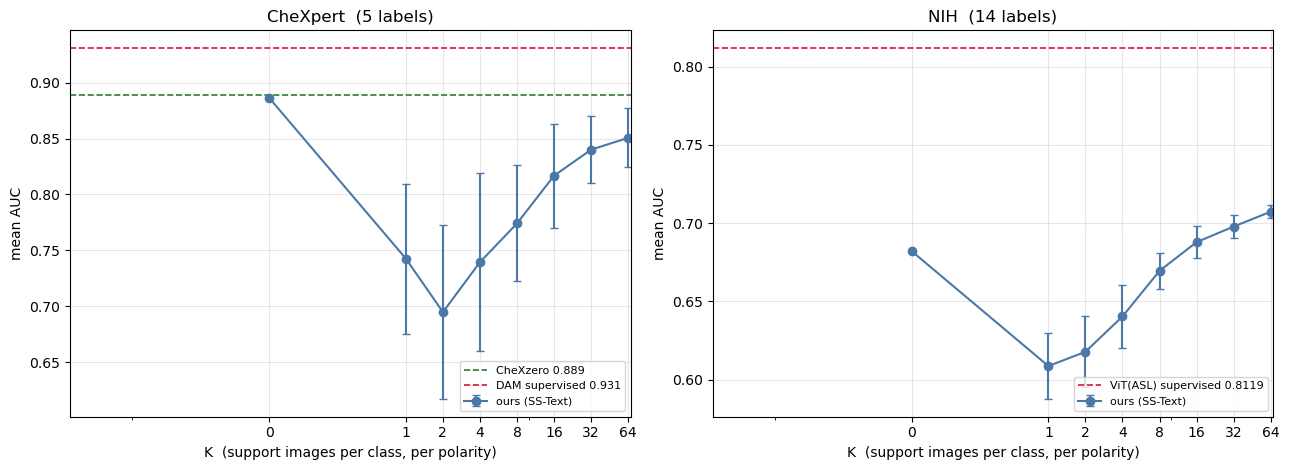

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (name, d) in zip(axes, DATA.items()):
    s = summary[summary.dataset == name]
    xs = [0] + list(s.K); ys = [d["ZS"]] + list(s["mean"]); es = [0] + list(s["std"])
    ax.errorbar(xs, ys, yerr=es, marker="o", capsize=3, color="#4C78A8", label="ours (SS-Text)")
    if name == "CheXpert":
        ax.axhline(0.889, ls="--", c="#2E7D32", lw=1.2, label="CheXzero 0.889")
        ax.axhline(0.931, ls="--", c="crimson", lw=1.2, label="DAM supervised 0.931")
    else:
        ax.axhline(0.8119, ls="--", c="crimson", lw=1.2, label="ViT(ASL) supervised 0.8119")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xticks([0] + K_SWEEP); ax.set_xticklabels(["0"] + [str(k) for k in K_SWEEP])
    ax.set_xlabel("K  (support images per class, per polarity)")
    ax.set_ylabel("mean AUC")
    ax.set_title(f"{name}  ({len(d['labels'])} labels)")
    ax.grid(alpha=.3); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "k_sweep_both.png"), dpi=150); plt.show()

### Deliverable 4 — head-to-head on the five shared pathologies

These five appear in **both** datasets. Same model, same prompts, same K — so the only thing
that differs is the test distribution and its labelling.

In [13]:
SHARED = [("Atelectasis", "Atelectasis"), ("Cardiomegaly", "Cardiomegaly"),
          ("Consolidation", "Consolidation"), ("Edema", "Edema"),
          ("Pleural Effusion", "Effusion")]
K_REF = 16
m16 = fs[fs.K == K_REF].groupby(["dataset", "label"])["auc"].mean()

rows = []
for cl, nl in SHARED:
    rows.append({"pathology": cl,
                 "CheXpert zero-shot": DATA["CheXpert"]["zs_auc"][cl],
                 f"CheXpert K={K_REF}": m16[("CheXpert", cl)],
                 "NIH zero-shot": DATA["NIH"]["zs_auc"][nl],
                 f"NIH K={K_REF}": m16[("NIH", nl)]})
h2h = pd.DataFrame(rows)
h2h["CheXpert delta"] = h2h[f"CheXpert K={K_REF}"] - h2h["CheXpert zero-shot"]
h2h["NIH delta"]      = h2h[f"NIH K={K_REF}"]      - h2h["NIH zero-shot"]
h2h.loc[len(h2h)] = ["MEAN"] + list(h2h.iloc[:, 1:].mean())
h2h.to_csv(os.path.join(OUT, "head_to_head.csv"), index=False)
display(h2h.style.format({c: "{:+.4f}" if "delta" in c else "{:.4f}"
                          for c in h2h.columns[1:]}).hide(axis="index"))

pathology,CheXpert zero-shot,CheXpert K=16,NIH zero-shot,NIH K=16,CheXpert delta,NIH delta
Atelectasis,0.8229,0.7105,0.6949,0.6450,-0.1124,-0.0499
Cardiomegaly,0.9087,0.7871,0.8290,0.8309,-0.1216,+0.0019
Consolidation,0.8866,0.8649,0.7068,0.7034,-0.0217,-0.0034
Edema,0.8894,0.8277,0.8129,0.7754,-0.0617,-0.0374
Pleural Effusion,0.9242,0.8938,0.7840,0.7524,-0.0304,-0.0317
MEAN,0.8864,0.8168,0.7655,0.7414,-0.0695,-0.0241


### Per-label effect of few-shot, both datasets

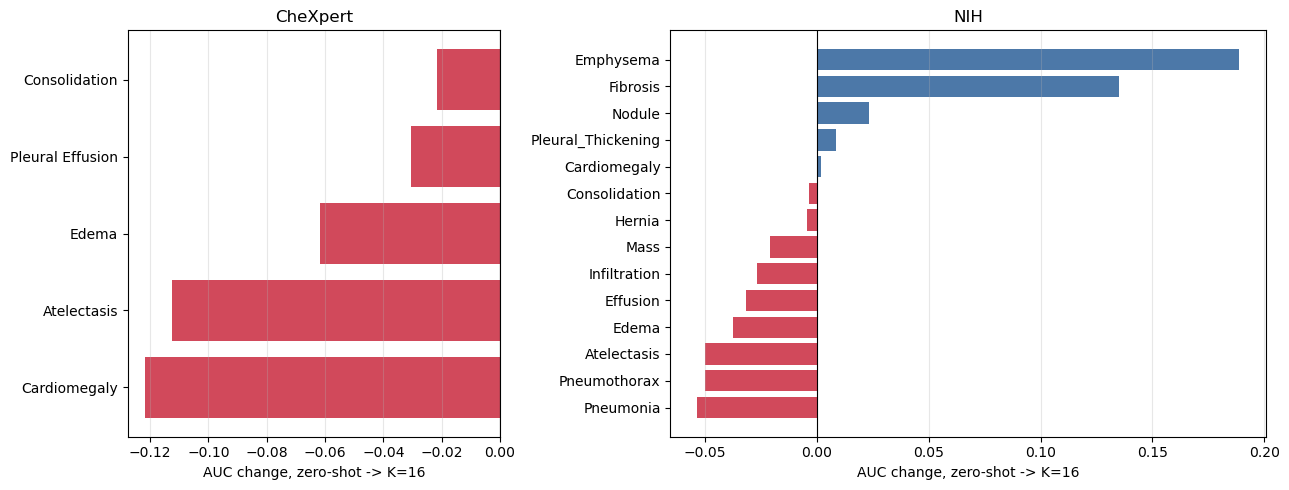


CheXpert: 0/5 labels improved at K=16, mean -0.0695

NIH: 5/14 labels improved at K=16, mean +0.0057


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.6]})
for ax, (name, d) in zip(axes, DATA.items()):
    pl = fs[(fs.K == K_REF) & (fs.dataset == name)].groupby("label")["auc"].mean()
    delta = (pl - pd.Series(d["zs_auc"])).loc[d["labels"]].sort_values()
    ax.barh(delta.index, delta.values,
            color=["#D1495B" if v < 0 else "#4C78A8" for v in delta.values])
    ax.axvline(0, c="k", lw=.8); ax.grid(axis="x", alpha=.3)
    ax.set_xlabel(f"AUC change, zero-shot -> K={K_REF}")
    ax.set_title(name)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "per_label_both.png"), dpi=150); plt.show()

for name, d in DATA.items():
    pl = fs[(fs.K == K_REF) & (fs.dataset == name)].groupby("label")["auc"].mean()
    delta = (pl - pd.Series(d["zs_auc"])).loc[d["labels"]]
    print(f"\n{name}: {int((delta > 0).sum())}/{len(delta)} labels improved at K={K_REF}, "
          f"mean {delta.mean():+.4f}")

In [15]:
best = summary.loc[summary.groupby("dataset")["mean"].idxmax()]
tbl = pd.DataFrame([
    {"dataset": "CheXpert", "method": "DAM (supervised SOTA)",     "labels": "100%", "mean AUC": 0.931},
    {"dataset": "CheXpert", "method": "DenseNet-121 (supervised)", "labels": "100%", "mean AUC": 0.902},
    {"dataset": "CheXpert", "method": "CheXzero zero-shot (paper)","labels": "0",    "mean AUC": 0.889},
    {"dataset": "CheXpert", "method": "ours, zero-shot",           "labels": "0",    "mean AUC": DATA["CheXpert"]["ZS"]},
    {"dataset": "NIH",      "method": "ViT(ASL) supervised, 9 labels", "labels": "100%", "mean AUC": 0.8119},
    {"dataset": "NIH",      "method": "ours, zero-shot",           "labels": "0",    "mean AUC": DATA["NIH"]["ZS"]},
])
for _, r in best.iterrows():
    n = len(DATA[r.dataset]["labels"])
    tbl.loc[len(tbl)] = [r.dataset, f"ours, SS-Text K={int(r.K)}",
                         f"{int(r.K)*2*n}", r["mean"]]
tbl = tbl.sort_values(["dataset", "mean AUC"], ascending=[True, False]).reset_index(drop=True)
tbl.to_csv(os.path.join(OUT, "comparison.csv"), index=False)
display(tbl.style.format({"mean AUC": "{:.4f}"}).hide(axis="index"))

dataset,method,labels,mean AUC
CheXpert,DAM (supervised SOTA),100%,0.9310
CheXpert,DenseNet-121 (supervised),100%,0.9020
CheXpert,CheXzero zero-shot (paper),0,0.8890
CheXpert,"ours, zero-shot",0,0.8864
CheXpert,"ours, SS-Text K=64",640,0.8506
NIH,"ViT(ASL) supervised, 9 labels",100%,0.8119
NIH,"ours, SS-Text K=64",1792,0.7073
NIH,"ours, zero-shot",0,0.6821


## 7. Read-out

Fill in once the cells above have run.

1. **Did we reproduce 0.889?** Section 4 gives the number and whether 0.889 sits inside our
   bootstrap CI. Remaining deviations if not: 8 epochs vs the paper's 4 (mitigated by selecting
   the best checkpoint wherever it lands), and all-views training where the paper's Methods
   describe AP/PA selection per study — a discrepancy the released code does not implement.

2. **The frequency prediction.** On ChestX-ray14 the previous run found few-shot helped *only*
   where the pathology was rare in MIMIC (Fibrosis +0.20, Emphysema +0.17) and hurt where it was
   common (Cardiomegaly −0.02, Effusion −0.04). **All five CheXpert competition tasks are common
   in MIMIC**, so the prediction is **little or no gain on CheXpert, possibly negative at low K**.
   The two panels in §6 test that directly, and the head-to-head table isolates it on the five
   shared pathologies — same model, same prompts, different test set.

3. **Label efficiency.** DAM 0.931 and DenseNet-121 0.902 used 100% of 223,414 labels. Whatever
   K it takes to approach them is the label-efficiency result.

4. **Caveat to carry into the write-up.** CheXpert support labels are machine-extracted and
   noisy; NIH support labels are clean. If CheXpert few-shot underperforms NIH, label noise is a
   competing explanation to the frequency account, and the two are not separated here.

In [16]:
print("saved to", OUT)
for f in sorted(os.listdir(OUT)):
    print(" ", f, f"{os.path.getsize(os.path.join(OUT, f))/1e6:.1f} MB")

saved to /mnt/My_Doc/experiments/chexpert_v1/results/
  comparison.csv 0.0 MB
  feat_CheXpert_supp_9637936f2a.npy 204.8 MB
  feat_CheXpert_test_bb876417dd.npy 10.2 MB
  feat_NIH_supp_32cfa6090d.npy 409.6 MB
  feat_NIH_test_987061f115.npy 524.2 MB
  fewshot_sweep.csv 0.1 MB
  head_to_head.csv 0.0 MB
  k_sweep_both.png 0.1 MB
  per_label_both.png 0.1 MB
  text_9382bb3d1b.npz 0.6 MB
